In [1]:
import pandas as pd
import numpy as np
import re 
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV 
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score, hamming_loss, jaccard_score
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)

data= pd.read_csv("anti_total.csv".strip('\u202a'), index_col=False)

In [3]:
start_index = data.columns.get_loc('Acyclovir')
end_index = data.columns.get_loc('tenofovir/emtricitabine/rilpivirine')

In [4]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [5]:
abx_cols = data.columns[start_index:end_index+1]
col_sum = data[abx_cols].sum()

In [6]:
final_cols = col_sum[col_sum >= 400].index.tolist()
base_cols = [c for c in data.columns if c not in abx_cols]
data_filter = data[base_cols + final_cols]

In [7]:
data_filter[final_cols].sum().sort_values(ascending=False)

Amoxicillin/Clavulanic acid    5515.0
Flomoxef                       5196.0
Cefazolin                      2371.0
Cefixime                       2166.0
Ciprofloxacin                  2071.0
Azithromycin                   2053.0
Cefuroxime                     1691.0
Piperacillin/Tazobactam        1511.0
Cefoperazone/sulbactam         1412.0
Peramivir                      1119.0
Baloxavir marboxil             1085.0
Metronidazole                  1020.0
Cefadroxil                      918.0
Oseltamivir                     835.0
Levofloxacin                    720.0
Clindamycin                     624.0
Gentamicin                      623.0
Ceftriaxone                     610.0
Cephalexin                      517.0
Ampicillin                      423.0
dtype: float64

In [8]:
all_site_cols = [
    'INFECTIONSITE1', 'INFECTIONSITE2', 'INFECTIONSITE3',
    'INFECTIONSITE4', 'INFECTIONSITE5', 'INFECTIONSITE9', 
    'OTHERINFECTIONSITE_flag'
]

temp_df = data_filter[all_site_cols].copy().astype(str).apply(lambda x: x.str.strip())
temp_df = temp_df.replace(['', 'nan', 'None', 'nan.0'], '0')

temp_df = temp_df.astype(float)

has_site_mask = (temp_df > 0).any(axis=1)

site_samples = data[has_site_mask].copy()

print(f"原始樣本數: {len(data)}")
print(f"至少標註一個部位的樣本數: {len(site_samples)}")
print(f"被排除掉的『全空/全0』樣本數: {len(data) - len(site_samples)}")


原始樣本數: 27968
至少標註一個部位的樣本數: 11880
被排除掉的『全空/全0』樣本數: 16088


In [9]:
len(site_samples), len(site_samples['ACCOUNTNO'])

(11880, 11880)

In [10]:
site_samples['Clindamycin'].sum(), site_samples['Gentamicin'].sum()

(379.0, 201.0)

In [11]:
roomno_mapping = {'A': '1', 'C': '2', 'D': '3', 'E': '4', 'H': '5', 'K': '6'}
site_samples['ROOMNO'] = site_samples['ROOMNO'].map(roomno_mapping)          

site_samples['SEX'] = site_samples['SEX'].map({'M': 1, 'F': 0})

yn_cols = [
    'ISSEPSIS0', 'FEVER', 'DM', 'CARDIOVASCULAR', 
    'RESPIRATORY', 'CNS', 'CANCER', 'LIVER', 'KIDNEY', 'AUTOIMMUNE'
]

for col in yn_cols:
    site_samples[col] = site_samples[col].map({'Y': 1, 'N': 0})

In [12]:
feature_cols = list(set(site_samples.columns) - set(abx_cols))
X = site_samples[feature_cols]
y = site_samples[final_cols]

In [13]:
X.shape, y.shape

((11880, 69), (11880, 20))

In [14]:
X = X.drop(columns=['ACCOUNTNO','ROOMNO', 'INTIME', 'Influenza Virus A level', 'FIRST_ORDERTIME', 'ISSEPSIS0'])
y = y.drop(columns=['Peramivir', 'Baloxavir marboxil', 'Oseltamivir', 'Cephalexin', 'Cefadroxil'])
                    #'Amoxicillin', 'Doxycycline', 'Acyclovir', 'Valaciclovir', 'Tenofovir alafenamide', 'Ceftazidime'])# 去掉抗病毒的藥(前3) 

In [15]:
# 找出至少有一種藥物的樣本 (Row sum > 0)
has_label_mask = (y.sum(axis=1) > 0)

# 同步過濾 X 和 y
X = X[has_label_mask]
y = y[has_label_mask]

print(f"原本樣本數: {len(has_label_mask)}")
print(f"過濾後樣本數: {len(y)}")
print(f"已刪除 {len(has_label_mask) - len(y)} 筆因刪除藥物欄位而變成『無給藥』的樣本")

原本樣本數: 11880
過濾後樣本數: 11470
已刪除 410 筆因刪除藥物欄位而變成『無給藥』的樣本


In [16]:
X.columns

Index(['Microscopic WBC level', 'FEVER', 'MAP', 'DM', 'CHECKITEM30SCORE',
       'RESPIRATORY', 'PLT', 'Bacteria level', 'VITALSIGNSPR', 'HST', 'K',
       'Nitrite level', 'StayTime_hours', 'RBC', 'WBC', 'CHECKITEM32SCORE',
       'INFECTIONSITE5', 'INR', 'CHECKITEM27', 'Lymphocyte', 'INFECTIONSITE4',
       'PH', 'VITALSIGNSGCS', 'VITALSIGNSDBP', 'O2 SAT', 'INJURELEVEL', 'HCO3',
       'Leukocyte level', 'CARDIOVASCULAR', 'Absolute Neutrophil count', 'SEX',
       'CHECKITEM31SCORE', 'INFECTIONSITE3', 'BE(ecf)', 'Ht', 'INFECTIONSITE1',
       'T.Bilirubin', 'INFECTIONSITE9', 'AUTOIMMUNE', 'CRP', 'APTT', 'GPT',
       'Hb', 'INFECTIONSITE2', 'CANCER', 'Creatinine', 'PT',
       'CHECKITEM27SCORE', 'AGE', 'CHECKITEM28SCORE', 'VITALSIGNSSPO2', 'Na',
       'VITALSIGNSRR', 'Neutrophil Seg.', 'CHECKITEM28A', 'LIVER', 'PCO2',
       'KIDNEY', 'Microscopic RBC level', 'VITALSIGNSBT', 'CHECKITEM29SCORE',
       'CNS', 'OTHERINFECTIONSITE_flag'],
      dtype='object')

In [17]:
y[y.columns].sum().sort_values(ascending=False)

Flomoxef                       5190.0
Amoxicillin/Clavulanic acid    1581.0
Piperacillin/Tazobactam        1509.0
Cefoperazone/sulbactam         1411.0
Metronidazole                   916.0
Ciprofloxacin                   872.0
Cefixime                        851.0
Azithromycin                    695.0
Ceftriaxone                     609.0
Cefazolin                       589.0
Levofloxacin                    501.0
Cefuroxime                      497.0
Clindamycin                     379.0
Gentamicin                      201.0
Ampicillin                       88.0
dtype: float64

In [18]:
# ####################### Missing 70~80% #######################

# # 檢驗

# X['Leukocyte level_flag'] = (
#      X['Leukocyte level'].fillna('').str.strip().ne('').astype(int))

# X['Nitrite level_flag'] = (
#      X['Nitrite level'].fillna('').str.strip().ne('').astype(int))

# X['Bacteria level_flag'] = (
#      X['Bacteria level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic RBC level_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))

# X['Microscopic WBC level_flag'] = (
#      X['Microscopic WBC level'].fillna('').str.strip().ne('').astype(int))

# X['PH_flag'] = (
#      X['Microscopic RBC level'].fillna('').str.strip().ne('').astype(int))



# # 計分

# X['CHECKITEM29SCORE_flag'] = (
#      X['CHECKITEM29SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM30SCORE_flag'] = (
#      X['CHECKITEM30SCORE'].fillna('').str.strip().ne('').astype(int))


# ####################### Missing > 80% #######################

# # 檢驗

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['T.Bilirubin_flag'] = (
#      X['T.Bilirubin'].fillna('').str.strip().ne('').astype(int))

# X['PT_flag'] = (
#      X['PT'].fillna('').str.strip().ne('').astype(int))

# X['HST_flag'] = (
#      X['HST'].fillna('').str.strip().ne('').astype(int))

# X['INR_flag'] = (
#      X['INR'].fillna('').str.strip().ne('').astype(int))

# X['APTT_flag'] = (
#      X['APTT'].fillna('').str.strip().ne('').astype(int))

# X['PCO2_flag'] = (
#      X['PCO2'].fillna('').str.strip().ne('').astype(int))

# X['HCO3_flag'] = (
#      X['HCO3'].fillna('').str.strip().ne('').astype(int))


# X['BE(ecf)_flag'] = (
#      X['BE(ecf)'].fillna('').str.strip().ne('').astype(int))

# X['O2 SAT_flag'] = (
#      X['O2 SAT'].fillna('').str.strip().ne('').astype(int))

# # 計分

# X['CHECKITEM28A_flag'] = (
#      X['CHECKITEM28A'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27_flag'] = (
#      X['CHECKITEM27'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM27SCORE_flag'] = (
#      X['CHECKITEM27SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM28SCORE_flag'] = (
#      X['CHECKITEM28SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM31SCORE_flag'] = (
#      X['CHECKITEM31SCORE'].fillna('').str.strip().ne('').astype(int))

# X['CHECKITEM32SCORE_flag'] = (
#      X['CHECKITEM32SCORE'].fillna('').str.strip().ne('').astype(int))


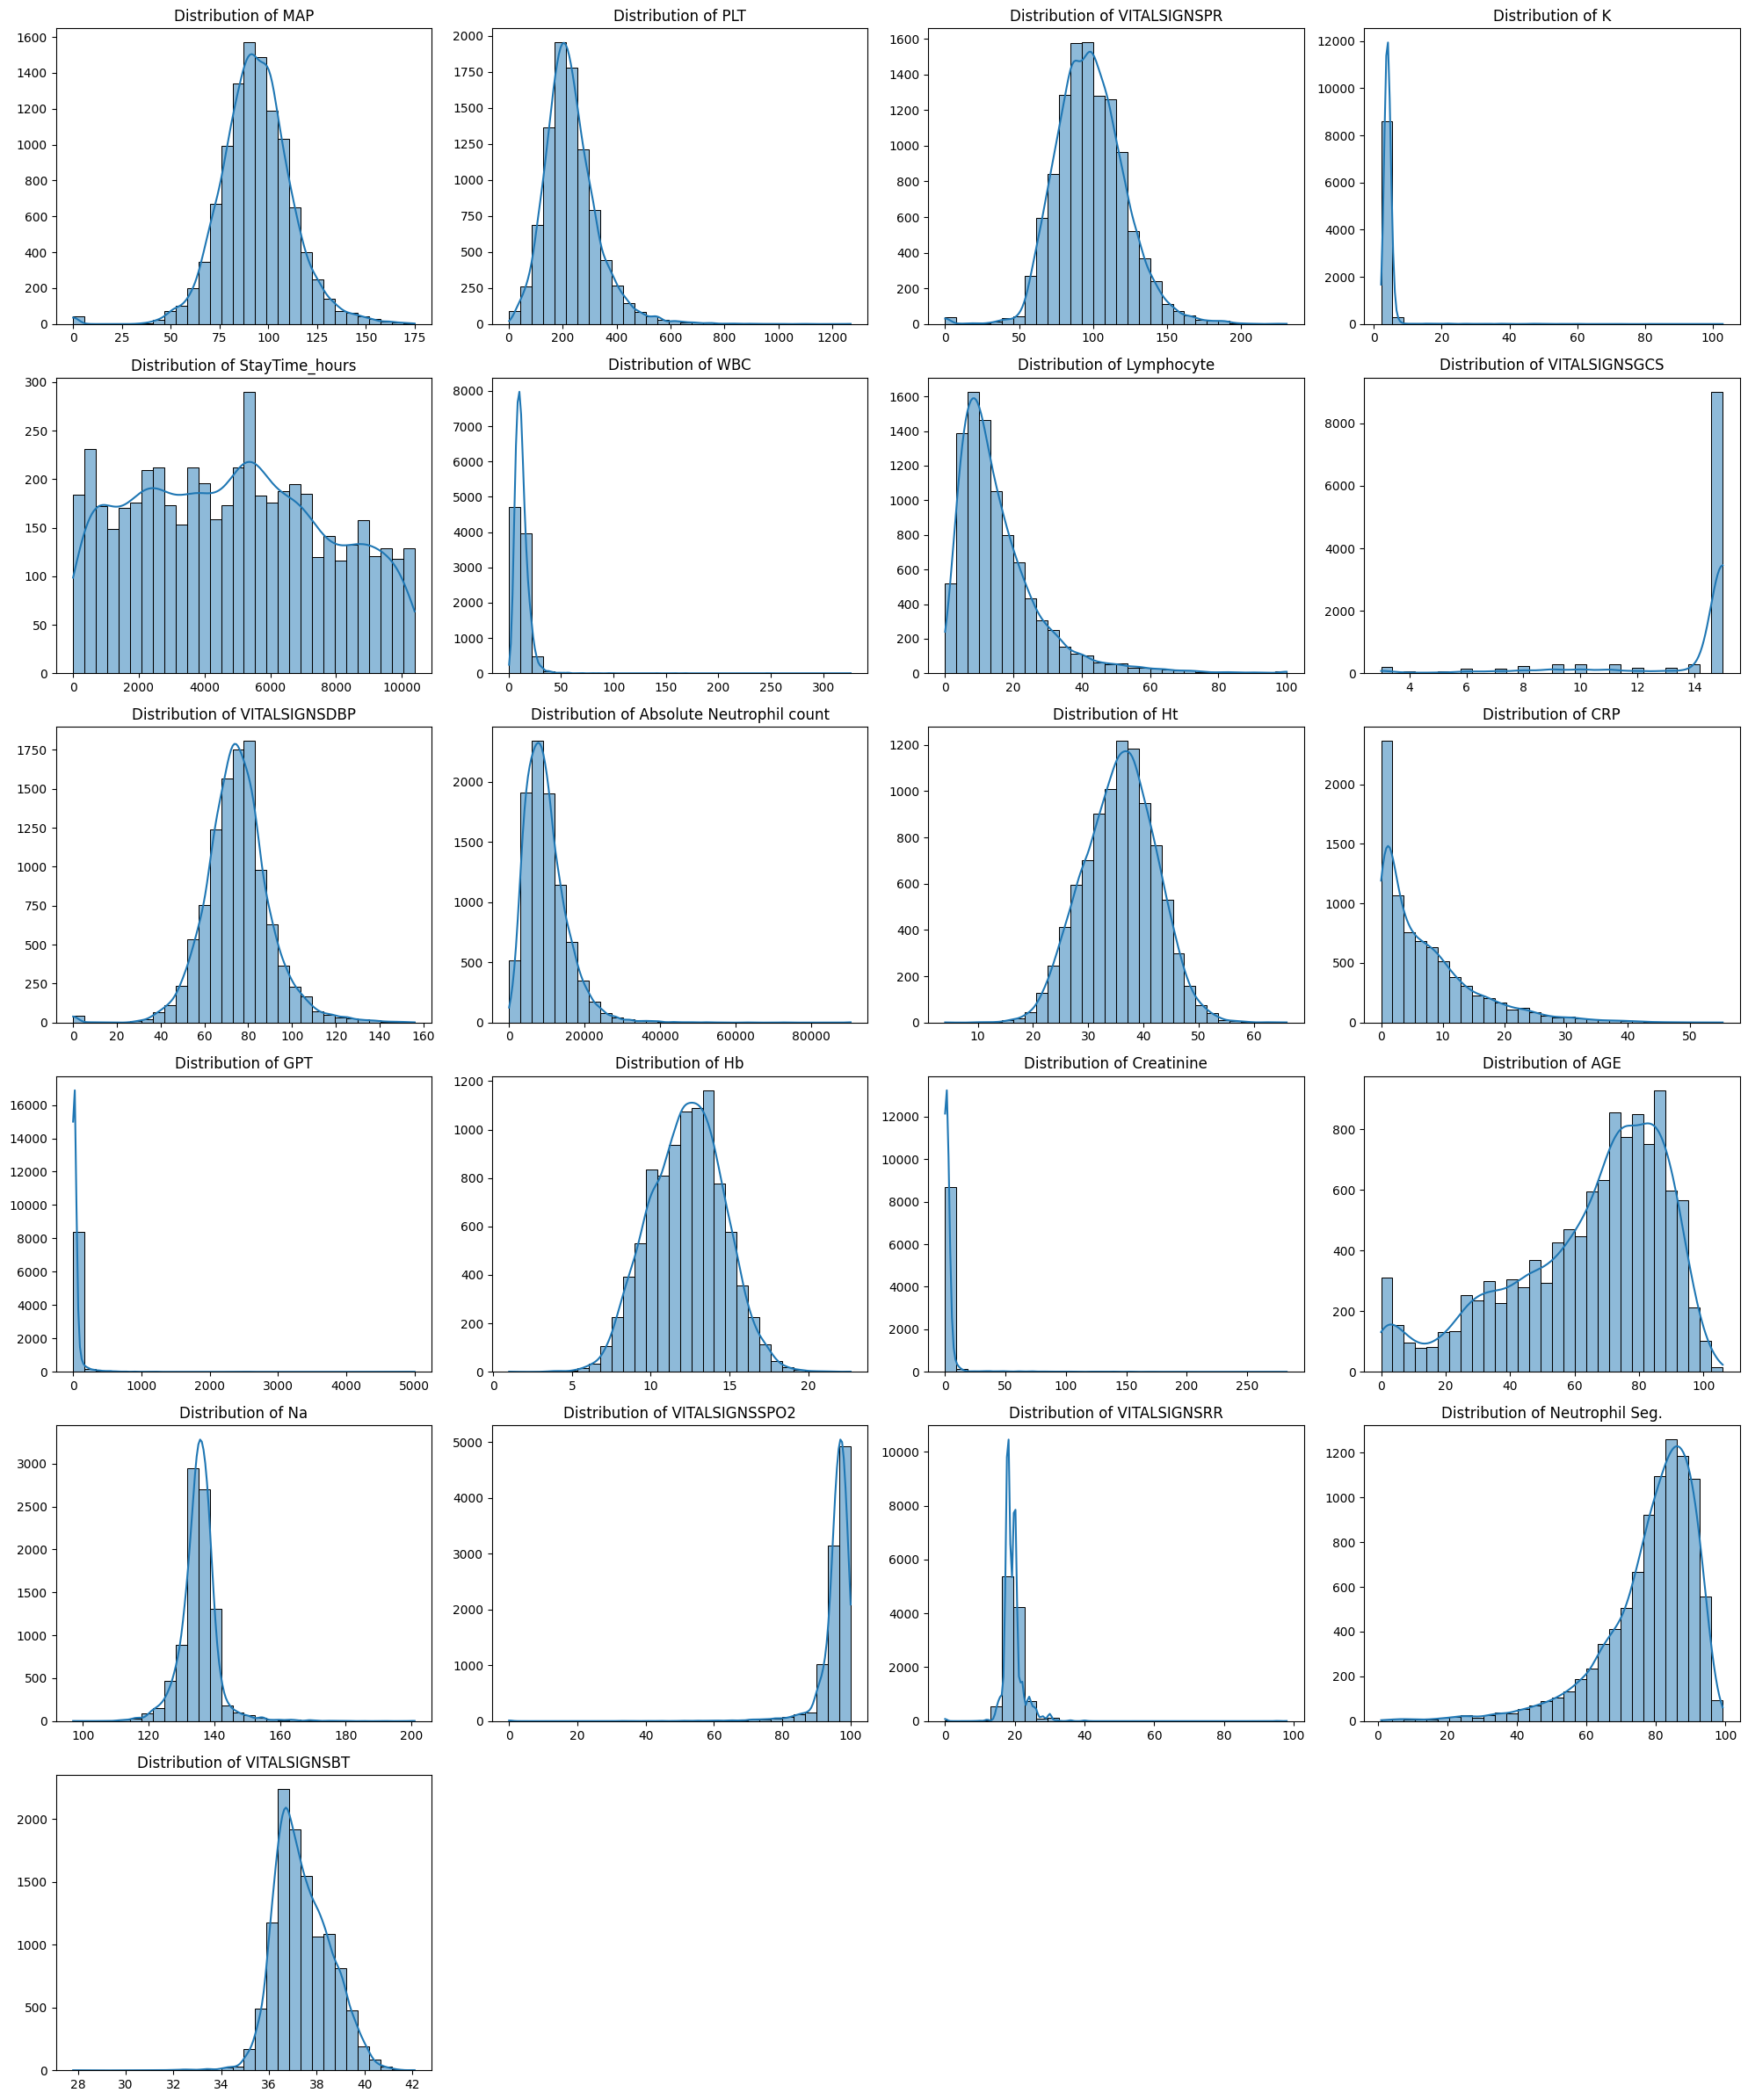

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

df = X

vital_cols = list(set(['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']))

# 設定每列顯示幾個圖
cols_per_row = 4
rows = math.ceil(len(vital_cols) / cols_per_row)

# 建立畫布
fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4))
axes = axes.flatten() # 將多維陣列拉平，方便迴圈讀取

for i, col in enumerate(vital_cols):
    if col in df.columns:
        # 繪製直方圖 + 密度曲線(kde)
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i], bins=30)
        axes[i].set_title(f'Distribution of {col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('')
    else:
        axes[i].set_axis_off() # 如果欄位不存在就留白

# 移除多餘的空白子圖
for j in range(i + 1, len(axes)):
    axes[j].set_axis_off()

plt.tight_layout()
plt.show()

In [20]:
lower_bound = X.quantile(0.01)
upper_bound = X.quantile(0.99)

outliers_low = (X < lower_bound).sum()
outliers_high = (X > upper_bound).sum()

outlier_summary = pd.DataFrame({
    'Low_Outliers (<1%)': outliers_low,
    'High_Outliers (>99%)': outliers_high,
    'Total_Outliers': outliers_low + outliers_high
})

print(f"全資料集總離群值筆數: {outlier_summary['Total_Outliers'].sum()}")
print("\n各欄位離群值統計 (前 10 名):")
print(outlier_summary.sort_values('Total_Outliers', ascending=False).head(10))


全資料集總離群值筆數: 4102

各欄位離群值統計 (前 10 名):
                           Low_Outliers (<1%)  High_Outliers (>99%)  \
VITALSIGNSPR                              105                   113   
MAP                                        99                   105   
VITALSIGNSDBP                             101                    98   
WBC                                        93                    93   
RBC                                        93                    93   
VITALSIGNSBT                               90                    96   
Ht                                         93                    91   
PLT                                        92                    92   
Absolute Neutrophil count                  92                    92   
Lymphocyte                                 84                    93   

                           Total_Outliers  
VITALSIGNSPR                          218  
MAP                                   204  
VITALSIGNSDBP                         199  
WBC  

In [21]:
# outlier修改為1%或99% quantile
X = X.clip(lower=lower_bound, upper=upper_bound, axis=1)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 123)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((9176, 63), (9176, 15), (2294, 63), (2294, 15))

In [23]:
X_train.isnull().sum(), X_test.isnull().sum()

(Microscopic WBC level      5148
 FEVER                         0
 MAP                         585
 DM                            0
 CHECKITEM30SCORE           5925
                            ... 
 Microscopic RBC level      5148
 VITALSIGNSBT                 65
 CHECKITEM29SCORE           5863
 CNS                           0
 OTHERINFECTIONSITE_flag       0
 Length: 63, dtype: int64,
 Microscopic WBC level      1306
 FEVER                         0
 MAP                         136
 DM                            0
 CHECKITEM30SCORE           1445
                            ... 
 Microscopic RBC level      1306
 VITALSIGNSBT                 12
 CHECKITEM29SCORE           1434
 CNS                           0
 OTHERINFECTIONSITE_flag       0
 Length: 63, dtype: int64)

In [24]:
X_train.dtypes, X_test.dtypes

(Microscopic WBC level      float64
 FEVER                        int64
 MAP                        float64
 DM                           int64
 CHECKITEM30SCORE           float64
                             ...   
 Microscopic RBC level      float64
 VITALSIGNSBT               float64
 CHECKITEM29SCORE           float64
 CNS                          int64
 OTHERINFECTIONSITE_flag      int64
 Length: 63, dtype: object,
 Microscopic WBC level      float64
 FEVER                        int64
 MAP                        float64
 DM                           int64
 CHECKITEM30SCORE           float64
                             ...   
 Microscopic RBC level      float64
 VITALSIGNSBT               float64
 CHECKITEM29SCORE           float64
 CNS                          int64
 OTHERINFECTIONSITE_flag      int64
 Length: 63, dtype: object)

In [25]:
y_train.sum().sort_values(ascending=False)

Flomoxef                       4148.0
Amoxicillin/Clavulanic acid    1253.0
Piperacillin/Tazobactam        1199.0
Cefoperazone/sulbactam         1140.0
Metronidazole                   752.0
Ciprofloxacin                   702.0
Cefixime                        695.0
Azithromycin                    544.0
Ceftriaxone                     489.0
Cefazolin                       466.0
Cefuroxime                      399.0
Levofloxacin                    394.0
Clindamycin                     300.0
Gentamicin                      171.0
Ampicillin                       78.0
dtype: float64

In [26]:
# 轉數值

num_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
            'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

for col in num_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')

In [27]:
# vital sign impute
vital_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
              'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']


for col in vital_cols:
    # X_train[col + "_missing"] = X_train[col].isna().astype(int) # missing indicator
    median = X_train[col].median()
    X_train[col] = X_train[col].fillna(median)
    
    # X_test[col + "_missing"] = X_test[col].isna().astype(int) # missing indicator
    X_test[col] = X_test[col].fillna(median)

In [28]:
# 取 log

X_train['CRP'] = np.log1p(X_train['CRP'])
X_test['CRP'] = np.log1p(X_test['CRP'])

X_train['PLT'] = np.log1p(X_train['PLT'])
X_test['PLT'] = np.log1p(X_test['PLT'])

X_train['RBC'] = np.log1p(X_train['RBC'])
X_test['RBC'] = np.log1p(X_test['RBC'])

X_train['WBC'] = np.log1p(X_train['WBC'])
X_test['WBC'] = np.log1p(X_test['WBC'])

X_train['AGE'] = np.log1p(X_train['AGE'])
X_test['AGE'] = np.log1p(X_test['AGE'])

X_train['K'] = np.log1p(X_train['K'])
X_test['K'] = np.log1p(X_test['K'])

X_train['GPT'] = np.log1p(X_train['GPT'])
X_test['GPT'] = np.log1p(X_test['GPT'])

X_train['VITALSIGNSSPO2'] = np.log1p(X_train['VITALSIGNSSPO2'])
X_test['VITALSIGNSSPO2'] = np.log1p(X_test['VITALSIGNSSPO2'])

X_train['Absolute Neutrophil count'] = np.log1p(X_train['Absolute Neutrophil count'])
X_test['Absolute Neutrophil count'] = np.log1p(X_test['Absolute Neutrophil count'])

X_train['VITALSIGNSBT'] = np.log1p(X_train['VITALSIGNSBT'])
X_test['VITALSIGNSBT'] = np.log1p(X_test['VITALSIGNSBT'])

X_train['VITALSIGNSRR'] = np.log1p(X_train['VITALSIGNSRR'])
X_test['VITALSIGNSRR'] = np.log1p(X_test['VITALSIGNSRR'])

X_train['Creatinine'] = np.log1p(X_train['Creatinine'])
X_test['Creatinine'] = np.log1p(X_test['Creatinine'])

X_train['Na'] = np.log1p(X_train['Na'])
X_test['Na'] = np.log1p(X_test['Na'])

# X_train['Lymphocyte'] = np.log1p(X_train['Lymphocyte'])
# X_test['Lymphocyte'] = np.log1p(X_test['Lymphocyte'])

In [29]:
# fill score
# score_cols = ['Leukocyte level_flag', 'Nitrite level_flag', 'Bacteria level_flag', 'Microscopic RBC level_flag', 'Microscopic WBC level_flag', 'PH_flag',
#               'CHECKITEM29SCORE_flag', 'CHECKITEM30SCORE_flag', # 70~80% missing
#               'HST_flag','T.Bilirubin_flag', 'PT_flag', 'HST_flag', 'INR_flag', 'APTT_flag', 'PCO2_flag', 'HCO3_flag', 'BE(ecf)_flag',
#               'O2 SAT_flag', 'CHECKITEM28A_flag', 'CHECKITEM27_flag', 'CHECKITEM27SCORE_flag', 'CHECKITEM28SCORE_flag', 
#               'CHECKITEM31SCORE_flag', 'CHECKITEM32SCORE_flag'] # > 80% missing

score_cols = ['Leukocyte level', 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level', 'PH',
              'CHECKITEM29SCORE', 'CHECKITEM30SCORE', # 70~80% missing
              'HST','T.Bilirubin', 'PT', 'HST', 'INR', 'APTT', 'PCO2', 'HCO3', 'BE(ecf)',
              'O2 SAT', 'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 
              'CHECKITEM31SCORE', 'CHECKITEM32SCORE'] # > 80% missing

for col in score_cols:
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    X_train[col] = X_train[col].fillna(-1)

    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].fillna(-1)

In [30]:
y_train.sum(axis=1).mean() # 每人平均用1.4個抗生素

1.3873147340889276

In [31]:
# drop_cols = ['HST', 'Leukocyte level' , 'Nitrite level', 'Bacteria level', 'Microscopic RBC level', 'Microscopic WBC level' , 
#              'PH', 'T.Bilirubin', 'PT' , 'INR', 'APTT', 'PCO2' , 'HCO3', 'BE(ecf)', 'O2 SAT', 
#              'CHECKITEM28A', 'CHECKITEM27', 'CHECKITEM27SCORE', 'CHECKITEM28SCORE', 'CHECKITEM29SCORE', 'CHECKITEM30SCORE', 
#              'CHECKITEM31SCORE', 'CHECKITEM32SCORE', 'OTHERINFECTIONSITE_flag']

drop_cols = ['OTHERINFECTIONSITE_flag']

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

In [32]:
scaled_cols = ['AGE', 'StayTime_hours', 'VITALSIGNSBT', 'VITALSIGNSPR', 'VITALSIGNSRR', 'VITALSIGNSSPO2', 'VITALSIGNSDBP', 'VITALSIGNSGCS', 'MAP', 'Hb', 'WBC', 
               'RBC', 'Ht', 'PLT', 'Lymphocyte', 'Neutrophil Seg.', 'Absolute Neutrophil count', 'Na', 'K', 'Creatinine', 'GPT', 'CRP']

scaler = StandardScaler()

X_train[scaled_cols] = scaler.fit_transform(X_train[scaled_cols])
X_test[scaled_cols] = scaler.fit_transform(X_test[scaled_cols])

In [33]:
X_train.shape
# X_train.to_csv('X_train_scale.csv')

(9176, 62)

In [34]:
y_train.columns

Index(['Amoxicillin/Clavulanic acid', 'Ampicillin', 'Azithromycin',
       'Cefazolin', 'Cefixime', 'Cefoperazone/sulbactam', 'Ceftriaxone',
       'Cefuroxime', 'Ciprofloxacin', 'Clindamycin', 'Flomoxef', 'Gentamicin',
       'Levofloxacin', 'Metronidazole', 'Piperacillin/Tazobactam'],
      dtype='object')

In [35]:
X_train.columns

Index(['Microscopic WBC level', 'FEVER', 'MAP', 'DM', 'CHECKITEM30SCORE',
       'RESPIRATORY', 'PLT', 'Bacteria level', 'VITALSIGNSPR', 'HST', 'K',
       'Nitrite level', 'StayTime_hours', 'RBC', 'WBC', 'CHECKITEM32SCORE',
       'INFECTIONSITE5', 'INR', 'CHECKITEM27', 'Lymphocyte', 'INFECTIONSITE4',
       'PH', 'VITALSIGNSGCS', 'VITALSIGNSDBP', 'O2 SAT', 'INJURELEVEL', 'HCO3',
       'Leukocyte level', 'CARDIOVASCULAR', 'Absolute Neutrophil count', 'SEX',
       'CHECKITEM31SCORE', 'INFECTIONSITE3', 'BE(ecf)', 'Ht', 'INFECTIONSITE1',
       'T.Bilirubin', 'INFECTIONSITE9', 'AUTOIMMUNE', 'CRP', 'APTT', 'GPT',
       'Hb', 'INFECTIONSITE2', 'CANCER', 'Creatinine', 'PT',
       'CHECKITEM27SCORE', 'AGE', 'CHECKITEM28SCORE', 'VITALSIGNSSPO2', 'Na',
       'VITALSIGNSRR', 'Neutrophil Seg.', 'CHECKITEM28A', 'LIVER', 'PCO2',
       'KIDNEY', 'Microscopic RBC level', 'VITALSIGNSBT', 'CHECKITEM29SCORE',
       'CNS'],
      dtype='object')

In [36]:
# GaussianMixture?

In [37]:
cluster_features = ['WBC', 'CRP', 'Lymphocyte', 'Neutrophil Seg.',  'Absolute Neutrophil count',  'Hb', 'Lymphocyte', 'MAP', 
                    'VITALSIGNSBT', 'VITALSIGNSDBP', 'VITALSIGNSRR', 'VITALSIGNSPR', 'VITALSIGNSGCS', 'VITALSIGNSSPO2']

gmm = GaussianMixture(n_components=3, covariance_type='diag', random_state=123)

In [38]:
X_train['cluster'] = gmm.fit_predict(X_train[cluster_features])
X_test['cluster'] = gmm.predict(X_test[cluster_features])

In [39]:
gmm.aic(X_train[cluster_features]), gmm.bic(X_train[cluster_features]), gmm.score(X_train[cluster_features])

(243807.45257269664, 244420.14638535422, -13.27568943835531)

In [40]:
X_train['cluster'].unique()

array([1, 0, 2], dtype=int64)

In [41]:
len(X_train[X_train['cluster'] == 0]), len(X_train[X_train['cluster'] == 1]), len(X_train[X_train['cluster'] == 2])

(1643, 6447, 1086)

In [42]:
#看看每個cluster的抗生素種類和分配
X_train_cluster = X_train.copy()
df_analysis = pd.concat([X_train_cluster, y_train], axis=1)

In [43]:
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_rate = subset[y_train.columns].mean().sort_values(ascending=False)
    print(drug_rate.head(15))

cluster 0
Flomoxef                       0.391357
Piperacillin/Tazobactam        0.230676
Cefoperazone/sulbactam         0.220937
Azithromycin                   0.065733
Ceftriaxone                    0.053561
Ciprofloxacin                  0.049909
Cefazolin                      0.047474
Levofloxacin                   0.047474
Amoxicillin/Clavulanic acid    0.035910
Cefixime                       0.032867
Metronidazole                  0.030432
Gentamicin                     0.022520
Cefuroxime                     0.020085
Clindamycin                    0.007304
Ampicillin                     0.000609
dtype: float64
cluster 1
Flomoxef                       0.475260
Amoxicillin/Clavulanic acid    0.154646
Cefoperazone/sulbactam         0.104235
Metronidazole                  0.103924
Piperacillin/Tazobactam        0.102994
Ciprofloxacin                  0.090740
Cefixime                       0.089809
Azithromycin                   0.058011
Ceftriaxone                    0.050876
Cefur

In [44]:
# 相對提升
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate).sort_values(ascending=False) # 明顯偏?
    print(lift.head(15))

cluster 0
Cefoperazone/sulbactam         1.778352
Piperacillin/Tazobactam        1.765371
Gentamicin                     1.208430
Azithromycin                   1.108768
Levofloxacin                   1.105641
Ceftriaxone                    1.005055
Cefazolin                      0.934813
Flomoxef                       0.865741
Ciprofloxacin                  0.652368
Cefuroxime                     0.461909
Cefixime                       0.433935
Metronidazole                  0.371337
Amoxicillin/Clavulanic acid    0.262976
Clindamycin                    0.223396
Ampicillin                     0.071601
dtype: float64
cluster 1
Clindamycin                    1.304690
Metronidazole                  1.268098
Ciprofloxacin                  1.186081
Cefixime                       1.185740
Cefuroxime                     1.152193
Amoxicillin/Clavulanic acid    1.132504
Flomoxef                       1.051346
Levofloxacin                   1.029543
Azithromycin                   0.978517
Cefaz

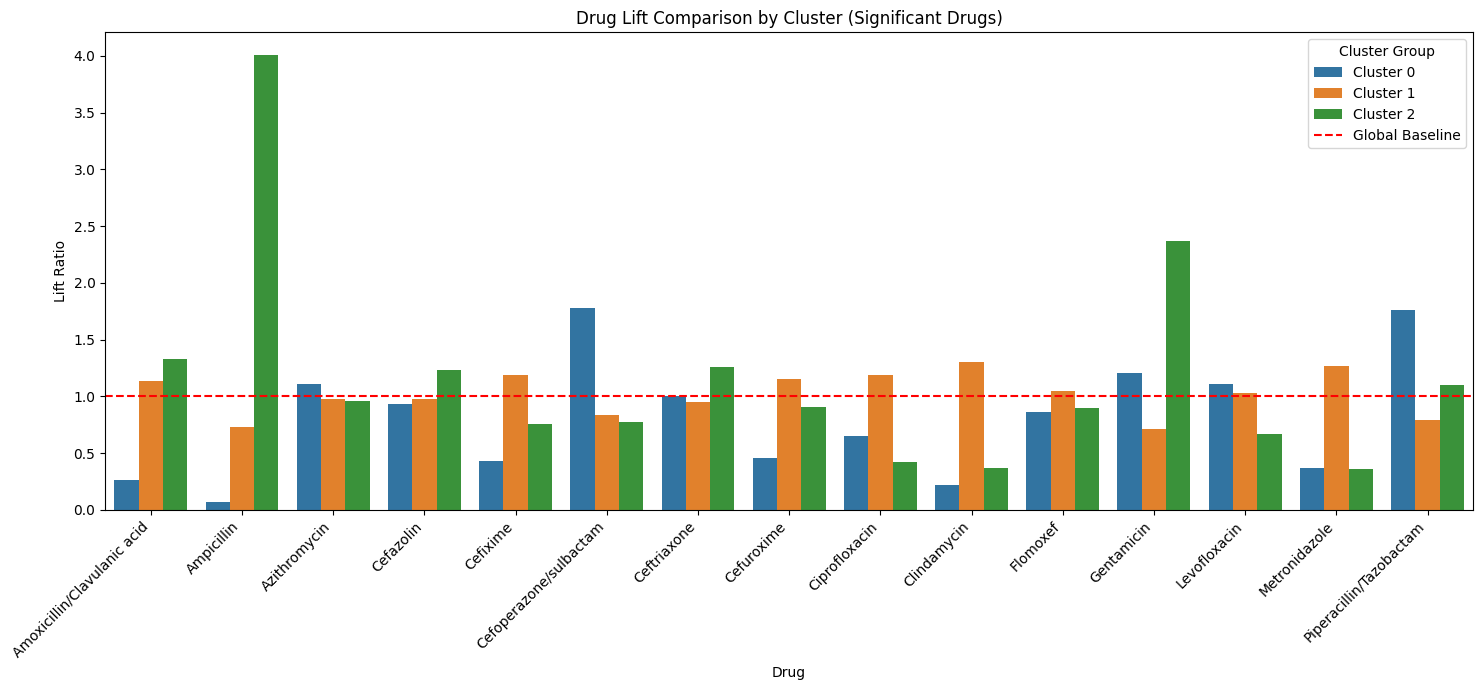

In [45]:
# 1. 整理資料存入 list
lift_records = []
global_rate = y_train.mean()

for c in sorted(df_analysis['cluster'].unique()):
    subset = df_analysis[df_analysis['cluster'] == c]
    cluster_rate = subset[y_train.columns].mean()
    lift = (cluster_rate / global_rate)
    
    for drug, val in lift.items():
        lift_records.append({
            'Cluster': f'Cluster {c}',
            'Drug': drug,
            'Lift': val
        })

df_lift_plot = pd.DataFrame(lift_records)

# 2. 繪圖：只挑出 Lift 較顯著的藥物（例如 Lift > 1.5 的藥物）
# 否則藥物太多圖會擠在一起
significant_drugs = df_lift_plot[df_lift_plot['Lift'] > 1.0]['Drug'].unique()
df_filtered = df_lift_plot[df_lift_plot['Drug'].isin(significant_drugs)]

plt.figure(figsize=(15, 7))
sns.barplot(data=df_filtered, x='Drug', y='Lift', hue='Cluster')

# 畫一條紅線代表基準線 (Lift=1)
plt.axhline(1, ls='--', color='red', label='Global Baseline')

plt.title('Drug Lift Comparison by Cluster (Significant Drugs)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Lift Ratio')
plt.legend(title='Cluster Group')
plt.tight_layout()
plt.show()


In [46]:
# 每群抗生素數量
for c in sorted(df_analysis['cluster'].unique()):
    print(f"cluster {c}")
    subset = df_analysis[df_analysis['cluster'] == c]
    drug_num = subset[y_train.columns].sum(axis=1).mean()
    print(drug_num)

cluster 0
1.2568472306755933
cluster 1
1.4366371955948503
cluster 2
1.2918968692449355


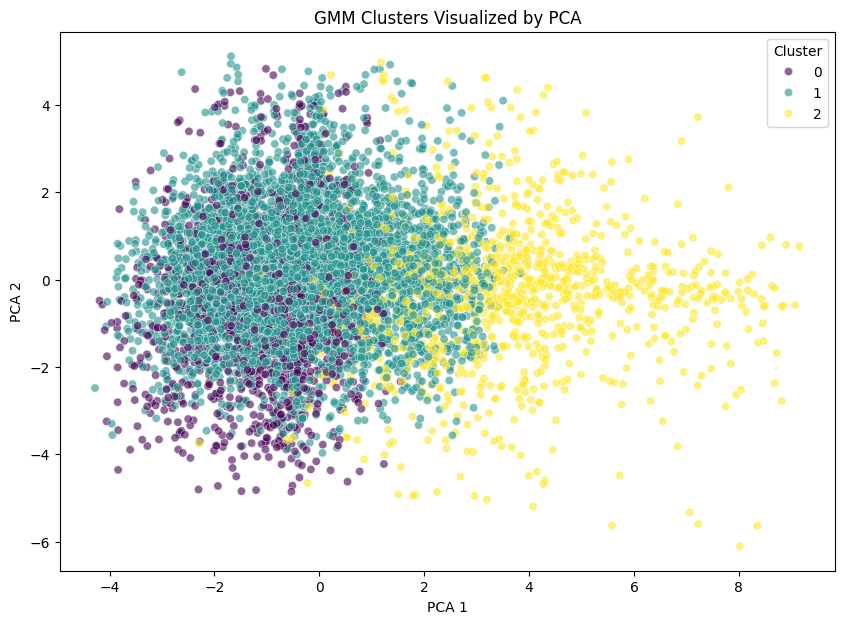

In [47]:
# PCA 降到 2 維
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train[cluster_features])

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_train_pca[:, 0], 
    y=X_train_pca[:, 1], 
    hue=X_train['cluster'], # 根據 GMM 分群上色
    palette='viridis', 
    alpha=0.6
)

plt.title('GMM Clusters Visualized by PCA')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster')
plt.show()


In [48]:
# 挑選關鍵重症指標
severity_indicators = cluster_features

cols_to_show = [c for c in severity_indicators if c in cluster_features]

cluster_summary = X_train.groupby('cluster')[cols_to_show].mean().T
cluster_summary # 0:、1:、2:

cluster,0,1,2
WBC,0.315382,0.048889,-0.767365
CRP,0.099120,0.053098,-0.465173
Lymphocyte,-0.444912,-0.222637,1.994781
Neutrophil Seg.,0.423776,0.190548,-1.772309
Absolute Neutrophil count,0.401069,0.115525,-1.292584
Hb,-0.283825,0.084798,-0.074002
Lymphocyte,-0.444912,-0.222637,1.994781
MAP,-0.091609,0.023815,-0.002780
VITALSIGNSBT,0.008236,0.034893,-0.219604
VITALSIGNSDBP,-0.148264,0.039989,-0.013084


In [49]:
# cluster prob
cluster_prob_train = gmm.predict_proba(X_train[cluster_features])
cluster_prob_test = gmm.predict_proba(X_test[cluster_features])

In [50]:
def cluster_prob(df, cluster_prob):
    cluster_df = pd.DataFrame(
        cluster_prob,
        columns=[f'cluster_{i}' for i in range(cluster_prob.shape[1])]
    )
    final_df = pd.concat([df.reset_index(drop=True), cluster_df], axis=1)
    return final_df

X_train = cluster_prob(X_train, cluster_prob_train)
X_test = cluster_prob(X_test, cluster_prob_test)

In [51]:
X_train.columns

Index(['Microscopic WBC level', 'FEVER', 'MAP', 'DM', 'CHECKITEM30SCORE',
       'RESPIRATORY', 'PLT', 'Bacteria level', 'VITALSIGNSPR', 'HST', 'K',
       'Nitrite level', 'StayTime_hours', 'RBC', 'WBC', 'CHECKITEM32SCORE',
       'INFECTIONSITE5', 'INR', 'CHECKITEM27', 'Lymphocyte', 'INFECTIONSITE4',
       'PH', 'VITALSIGNSGCS', 'VITALSIGNSDBP', 'O2 SAT', 'INJURELEVEL', 'HCO3',
       'Leukocyte level', 'CARDIOVASCULAR', 'Absolute Neutrophil count', 'SEX',
       'CHECKITEM31SCORE', 'INFECTIONSITE3', 'BE(ecf)', 'Ht', 'INFECTIONSITE1',
       'T.Bilirubin', 'INFECTIONSITE9', 'AUTOIMMUNE', 'CRP', 'APTT', 'GPT',
       'Hb', 'INFECTIONSITE2', 'CANCER', 'Creatinine', 'PT',
       'CHECKITEM27SCORE', 'AGE', 'CHECKITEM28SCORE', 'VITALSIGNSSPO2', 'Na',
       'VITALSIGNSRR', 'Neutrophil Seg.', 'CHECKITEM28A', 'LIVER', 'PCO2',
       'KIDNEY', 'Microscopic RBC level', 'VITALSIGNSBT', 'CHECKITEM29SCORE',
       'CNS', 'cluster', 'cluster_0', 'cluster_1', 'cluster_2'],
      dtype='object')

In [52]:
X_train = X_train.drop(columns='cluster')
X_test = X_test.drop(columns='cluster')

base_model = XGBClassifier(n_estimators=300,
                           max_depth=5,
                           learning_rate=0.05,
                           subsample=0.8,
                           colsample_bytree=0.8,
                           eval_metric='logloss',
                           gamma=0,
                           reg_alpha=2,
                           reg_lambda=0.0,
                           min_child_weight=1,
                           scale_pos_weight=3,
                           random_state =123,
                           n_jobs=-1
    )

multi_model = MultiOutputClassifier(base_model)
multi_model.fit(X_train, y_train) # sample_weight=sample_weight

,estimator,"XGBClassifier...ree=None, ...)"
,n_jobs,None
,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [53]:
y_pred_train = multi_model.predict(X_train)
print(f1_score(y_train, y_pred_train, average='micro'))
print(f1_score(y_train, y_pred_train, average='macro'))

0.843805842237701
0.8942004870451288


In [54]:
# # # 原始機率
y_prob_list = np.column_stack([multi_model.predict_proba(X_test)[:, 1] for multi_model in multi_model.estimators_])
y_pred = multi_model.predict(X_test)
# print(y_pred[:5])

# 計算每種抗生素的使用頻率
drug_freq = y_train.mean(axis=0).values
drug_freq = np.clip(drug_freq, 1e-6, None) #避免除以0

# 計算每種抗生素權重(F1/recall)
drug_weight = []

# 用y_train去計算f1，或用cv
for i, col in enumerate(y_train.columns):
    # score = 1 / (f1_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    score = 1 / (recall_score(y_train.values[:, i], y_pred_train[:, i], average='binary') + 1e-6)
    drug_weight.append(score)

drug_weight = np.clip(drug_weight, 1e-6, None)

#  normalize
drug_weight = drug_weight / drug_weight.mean()

alpha = 0.3 # penalty
belta = 1.0

# adjusted_scores = y_prob_list / (drug_freq ** alpha)
# adjusted_scores = np.log(y_prob_list + 1e-6) - np.log(drug_freq ** alpha)
adjusted_scores = (np.log(y_prob_list + 1e-6)+ belta * np.log(drug_weight)- alpha * np.log(drug_freq))
# adjusted_scores = y_prob_list * drug_weight ** belta - alpha * np.log(drug_freq)


In [55]:
# adjusted_scores MinMax
# adjusted_scores = (adjusted_scores - adjusted_scores.min(axis=1, keepdims=True)) / (adjusted_scores.max(axis=1, keepdims=True) - adjusted_scores.min(axis=1, keepdims=True) + 1e-9)

In [56]:
print(f1_score(y_test, y_pred, average='micro'))
print(f1_score(y_test, y_pred, average='macro'))

0.5115732975511573
0.33184334607163507


In [57]:
jaccard_score(y_test, y_pred, average='samples', zero_division=0)

0.45429380993897117

In [58]:
hamming_loss(y_test, y_pred)

0.08462656204591688

In [59]:
target_names = y_train.columns

for i, col in enumerate(target_names):
    print(f'-- {col} --')
    print(classification_report(y_train.iloc[:, i], y_pred_train[:, i]))

-- Amoxicillin/Clavulanic acid --
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98      7923
         1.0       0.85      0.95      0.89      1253

    accuracy                           0.97      9176
   macro avg       0.92      0.96      0.94      9176
weighted avg       0.97      0.97      0.97      9176

-- Ampicillin --
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00      9098
         1.0       1.00      1.00      1.00        78

    accuracy                           1.00      9176
   macro avg       1.00      1.00      1.00      9176
weighted avg       1.00      1.00      1.00      9176

-- Azithromycin --
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99      8632
         1.0       0.90      0.94      0.92       544

    accuracy                           0.99      9176
   macro avg       0.95      0.96      0.96      9176
weig

In [60]:
# top k hits rate

def hit_rate_at_k(y_true, proba, k=3):
    
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(set(actual)& set(topk[i].tolist())):
            hits += 1
    return hits /  len(y_true)

# precision@3
def precision_at_k(y_true, proba, k=3):
    # 處理 MultiOutputClassifier 的 proba 格式 (list of arrays)
    if isinstance(proba, list):
       proba = np.column_stack([p[:, 1] for p in proba])
    
    # 取得機率最高的前 k 個索引
    topk = np.argsort(proba, axis=1)[:, -k:]
    
    total_precision = 0
    for i in range(len(y_true)):
        # 該病患實際有開的藥物索引
        actual = set(np.where(y_true[i] == 1)[0])
        # 預測的前 k 個藥物索引
        predicted = set(topk[i].tolist())
        
        # 交集數量 (中了幾個) / 推薦數量 k
        hits = len(actual & predicted)
        total_precision += (hits / k)
        
    # 回傳所有樣本的平均 Precision@k
    return total_precision / len(y_true)

# recall@3

def recall_at_k(y_true, proba, k=3):
    if isinstance(proba, list):
        proba = np.column_stack([p[:, 1] for p in proba])

    topk = np.argsort(proba, axis=1)[:, -k:]
    hits = 0
    recalls = []
    for i in range(len(y_true)):
        actual = np.where(y_true[i]==1)[0]
        if len(actual) == 0:
            continue
        recall = len(set(actual) & set(topk[i])) / len(actual)
        recalls.append(recall)
    return np.mean(recalls)

# MAP@3

def map_at_k(y_true, scores, k=3):

    topk = np.argsort(scores, axis=1)[:, ::-1][:, :k]  # 排序

    APs = []

    for i in range(len(y_true)):
        actual = np.where(y_true[i] == 1)[0]

        if len(actual) == 0:
            continue

        hits = 0
        score = 0

        for j in range(k):
            if topk[i][j] in actual:
                hits += 1
                score += hits / (j + 1)

        APs.append(score / min(len(actual), k))

    return np.mean(APs)


################################

k=5
hitk = hit_rate_at_k(y_test.values, adjusted_scores, k=k)
print(f"Hit@{k}: {hitk}")
precisionk = precision_at_k(y_test.values, adjusted_scores, k=k)
print(f"precision@{k}: {precisionk}")
recall_k = recall_at_k(y_test.values, adjusted_scores, k=k)
print(f"Recall@{k}: {recall_k}")
map_k = map_at_k(y_test.values, adjusted_scores, k=k)
print(f"MAP@{k}: {map_k}")

Hit@5: 0.9241499564080209
precision@5: 0.23714036617261913
Recall@5: 0.8748910200523103
MAP@5: 0.634579337401918


In [61]:
hit1 = hit_rate_at_k(y_test.values, adjusted_scores, k=1)
hit1

0.5187445510026155

In [62]:
drug_names = y_train.columns


def show_top3_prediction(patient_idx, proba_matrix, y_true, drug_names, k=3):
    #預測
    probs = proba_matrix[patient_idx]
    topk_idx = np.argsort(probs)[-k:][::-1]

    #實際
    actual_idx = np.where(y_true[patient_idx] == 1)[0]
    actual_drugs = drug_names[actual_idx].tolist()

    print(f"實際給藥: {actual_drugs if actual_drugs else '無'}")
    print("\n推薦藥物:")
    for rank, idx in enumerate(topk_idx, 1):
        print(f"{rank}. {drug_names[idx]} (Score: {probs[idx]:.4f})")
    print("="*50)

for i in range(10):
    show_top3_prediction(i, adjusted_scores, y_test.values, drug_names, k=5)

實際給藥: ['Cefoperazone/sulbactam']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 0.0578)
2. Azithromycin (Score: 0.0325)
3. Flomoxef (Score: -0.0214)
4. Cefixime (Score: -0.4811)
5. Piperacillin/Tazobactam (Score: -0.5801)
實際給藥: ['Levofloxacin']

推薦藥物:
1. Cefazolin (Score: -0.0363)
2. Flomoxef (Score: -0.2215)
3. Ciprofloxacin (Score: -1.0787)
4. Cefuroxime (Score: -1.4403)
5. Piperacillin/Tazobactam (Score: -1.5850)
實際給藥: ['Piperacillin/Tazobactam']

推薦藥物:
1. Cefoperazone/sulbactam (Score: 0.2158)
2. Piperacillin/Tazobactam (Score: -0.1527)
3. Azithromycin (Score: -0.3093)
4. Levofloxacin (Score: -1.1062)
5. Flomoxef (Score: -1.6332)
實際給藥: ['Levofloxacin']

推薦藥物:
1. Cefoperazone/sulbactam (Score: -0.1118)
2. Azithromycin (Score: -0.1166)
3. Flomoxef (Score: -0.2596)
4. Cefixime (Score: -0.6343)
5. Levofloxacin (Score: -0.8777)
實際給藥: ['Piperacillin/Tazobactam']

推薦藥物:
1. Piperacillin/Tazobactam (Score: 0.2401)
2. Levofloxacin (Score: -0.3591)
3. Cefoperazone/sulbactam (Score: -0.6511)
4. Azit